In [1]:
user = "\SagixOffice"  # HomeOffice
#user = "\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import matplotlib.pyplot as plt
import src.fluorophore_systems as fs
import src.custom_plot as cp
import src.large_scale as ls
import src.figures as fi
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

# 1 Fluorophore - intensity distributions

## Only S0 S1 transitions

In [2]:
rate_dict = dict(k_S0_S1=1e15,  # excitation
                 k_S1_S0=1e8)  # emission

In [4]:
system = fs.JablonskiModel(number=1, distances=1, rates=rate_dict)

In [5]:
time_series, time_step_series, state_series = system.simulate(n_steps=1000000, seed=99, base="cy")

In [6]:
unique_series_converted, unique_states, occupation_time_mean = system.process()

In [7]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.001ms",
                                                                        photon_collection=1)

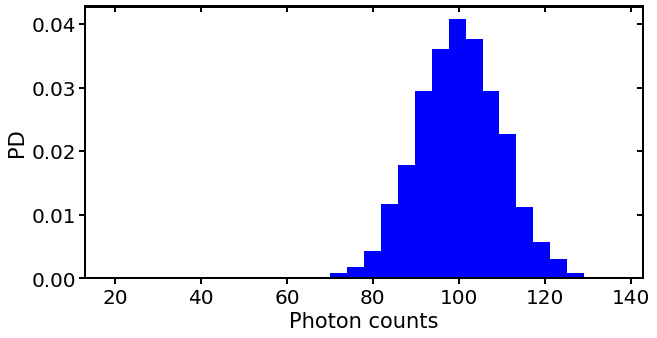

In [8]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=30)

### Saturation of intensity with increasing k_S0_S1 (due to increasing laser intensity)

In [14]:
#ks = np.logspace(6, 20, 50)
ks = np.arange(1e7, 1e8, 1e7)
means = []
for k in ks:
    rate_dict["k_S0_S1"] = k
    system = fs.JablonskiModel(number=1, distances=1, rates=rate_dict)
    time_series, time_step_series, state_series = system.simulate(n_steps=100000, seed=99, base="cy")
    unique_series_converted, unique_states, occupation_time_mean = system.process()
    emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.01ms")
    mean = np.mean(pandas_series.values)
    means.append(mean)

In [15]:
import matplotlib.pyplot as plt

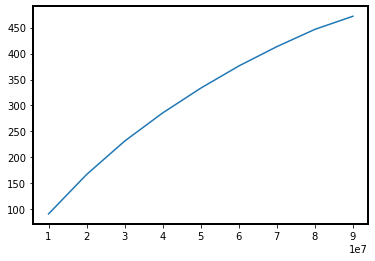

In [17]:
plt.plot(ks, means)
#plt.xscale("log")

In [18]:
#ks = np.logspace(6, 20, 50)
ks = np.arange(1e8, 1e9, 1e8)
means = []
for k in ks:
    rate_dict["k_S0_S1"] = k
    system = fs.JablonskiModel(number=1, distances=1, rates=rate_dict)
    time_series, time_step_series, state_series = system.simulate(n_steps=100000, seed=99, base="cy")
    unique_series_converted, unique_states, occupation_time_mean = system.process()
    emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.01ms")
    mean = np.mean(pandas_series.values)
    means.append(mean)

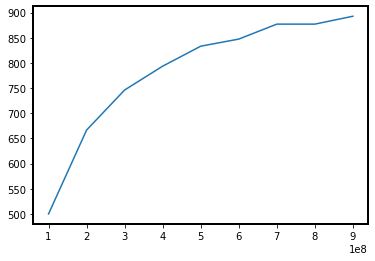

In [19]:
plt.plot(ks, means)

## Only S0, S1, T1

In [21]:
rate_dict = dict(k_S0_S1=1e15,  # excitation
                 k_S1_S0=1e8,  # emission
                 k_S1_T1=1e6,  # isc
                 k_T1_S0=1e5)  # phosphoresence

In [22]:
system = fs.JablonskiModel(number=1, distances=1, rates=rate_dict)

In [23]:
time_series, time_step_series, state_series = system.simulate(n_steps=10000000, seed=99, base="cy")

In [24]:
unique_series_converted, unique_states, occupation_time_mean = system.process()

### 0.0001 ms binning

In [25]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.0001ms")

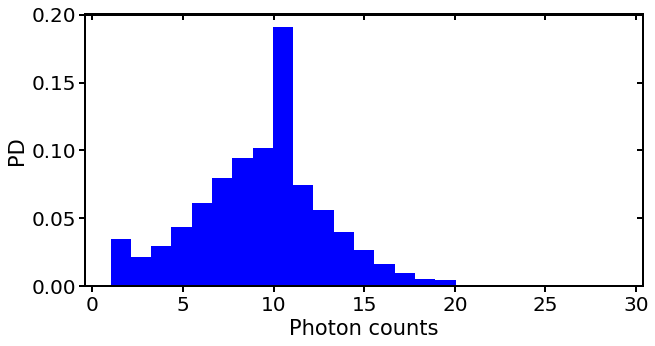

In [26]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 0.001 ms binning

In [103]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.001ms")

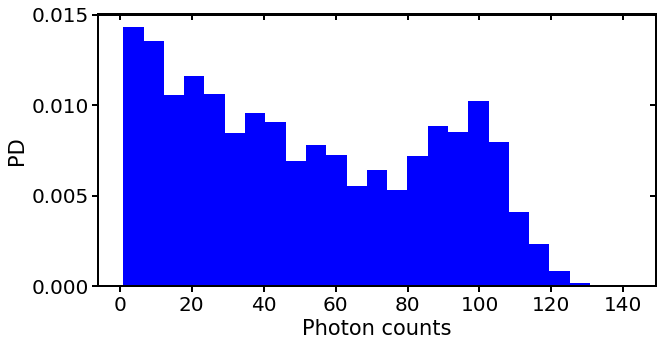

In [104]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 0.01 ms binning

Up from a certain minimum bin size, the intensity distribution resembles a exponential distribution, which then shifts to a gamma and finally to a normal distribution.

In experiments, binning happens first when the camera summarizes all detected signals into one localization during a certain time delta (e.g. 5 ms). This can for example lead to an exponential distribution.

Sometimes, another binning step is carried out later, e.g. by summarizing all localizations in consecutive frames (on frames). Hereby, a gamma distribution (or Erlangen) may be the result. 

These distributions depend on the triplet state T1, they cannot be observed in the S0 S1 state system. Explanation: ...

In [105]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.01ms")

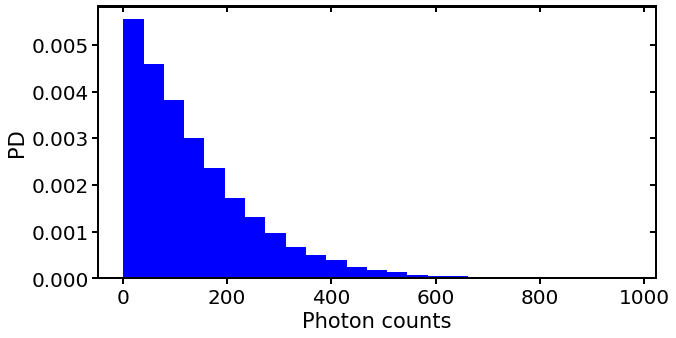

In [106]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 0.03 ms binning

In [107]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.03ms")

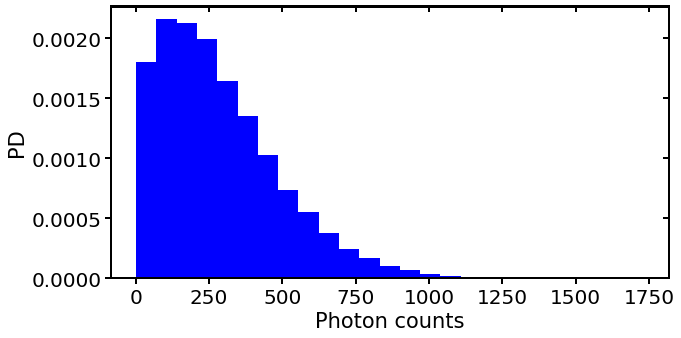

In [108]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 0.1 ms binning

In [109]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.1ms")

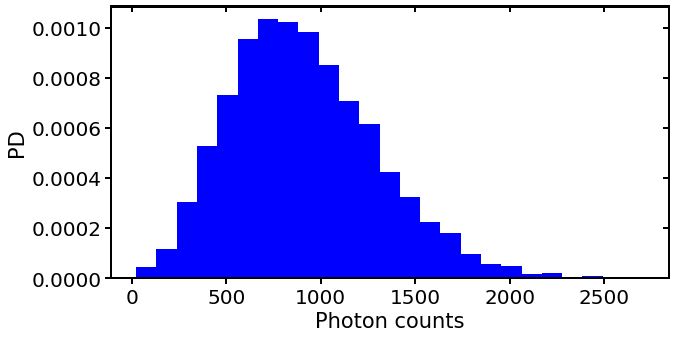

In [110]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 1 ms binning

In [113]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="1ms")

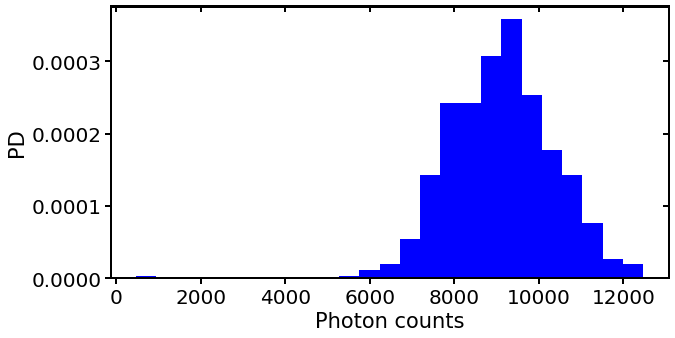

In [114]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

1	Exponentielle Intensitätsverteilungen kommen von einem An/Aus Prozess der auf Zeitskalen ~100fach unter der Bin-Zeit stattfindet.\
2	In dSTORM daten sehen wir immer exponentielle Verteilungen – ausser wir mitteln über An-Perioden (wie bei Sebastian vdL oder Domi).\
3	Triplet reicht nicht, um exponentielle Verteilungen in 10 ms bins zu erzeugen.\
4	Im Prinzip müsste man aus Intensitätsverteilungen die An/Aus Raten für einfache Systeme bestimmen können. Das könnte interessant sein für interagierende Farbstoffpaare, in denen wir die AusZustände nicht mehr auflösen können.

Die nächsten Fragen:

1	Wie sieht eine typische cis Komponente aus (in Verbindung mit Triplet) für einzelne Cy5? Reicht cis, um exponentielle Intensitätsverteilungen für 10 ms bins zu erzeugen?\
2	Wie sieht die Kurve aus, wenn Du Reduktions-Raten annimmst, die zu mittleren An/Auss Zeiten führen, wie wir sie im Experiment beobachten?


## S0, S1, T, R

In [125]:
rate_dict = dict(k_S0_S1=1e15,  # excitation
                 k_S1_S0=1e8,  # emission
                 k_S1_T1=1e6,  # isc
                 k_T1_S0=1e5,  # phosphoresence
                 k_T1_R=1e4,  # reduction
                 k_R_S0=0.5e0)  # oxidation 

In [126]:
system = fs.JablonskiModel(number=1, distances=1, photon_collection=0.2, rates=rate_dict)

In [141]:
time_series, time_step_series, state_series = system.simulate(n_steps=1000000, seed=99, base="cy")

In [142]:
unique_series_converted, unique_states, occupation_time_mean = system.process()

### 0.01 ms binning

In [144]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.01ms")

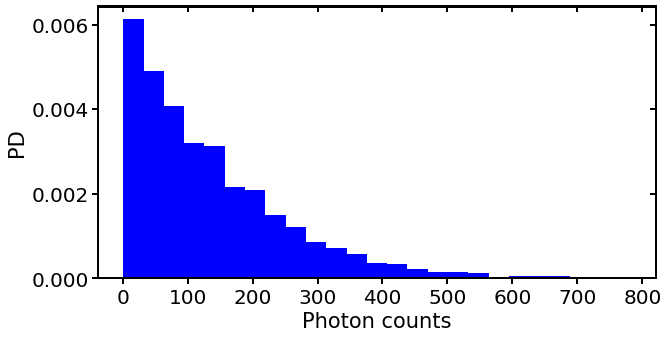

In [145]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 0.03 ms binning

In [150]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.03ms")

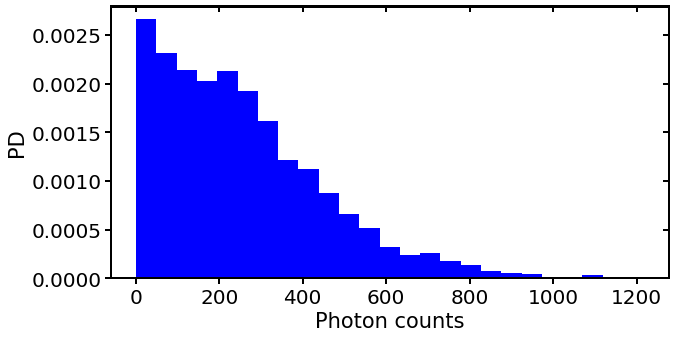

In [151]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 0.1 ms binning

In [146]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="0.1ms")

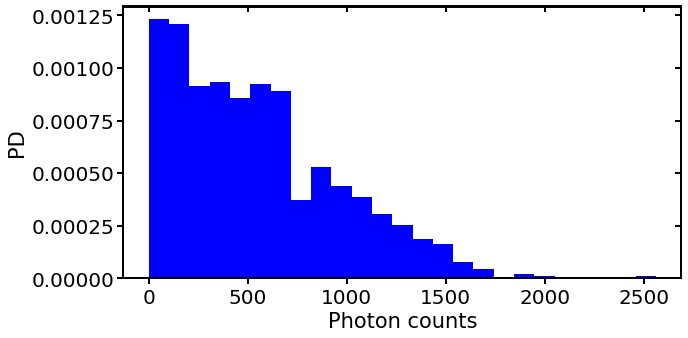

In [147]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 1 ms binning

In [148]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="1ms")

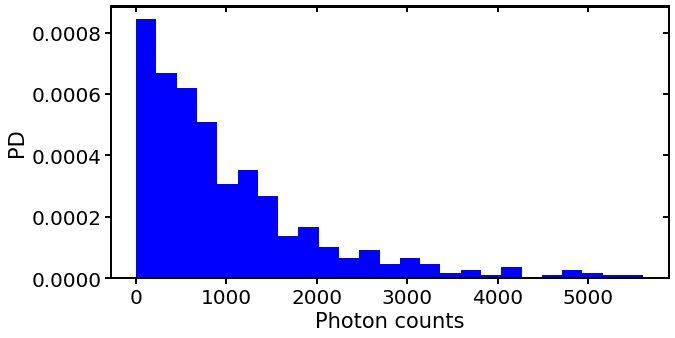

In [149]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

### 10 ms binning

In [152]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="10ms")

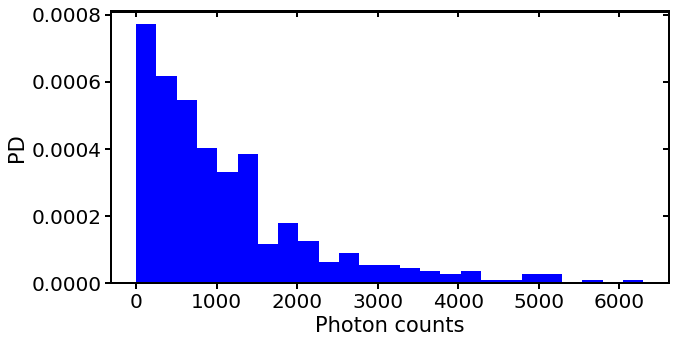

In [153]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)

In [174]:
emitting_mask, pandas_series, on_periods, off_periods = system.emitters(unit="s", resample="10000ms")

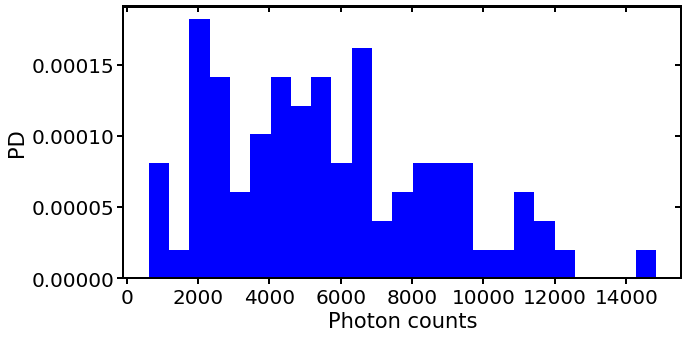

In [175]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=25)